# Keypoint Combining – MediaPipe & MoveNet

Shared joints (nose, left_ear, shoulders, elbows, wrists, hips, knees, ankles):
1. MediaPipe visibility ≥ 0.6 → use MediaPipe
2. MediaPipe interpolated (short gap, linear fill) → use MediaPipe
3. MoveNet confidence ≥ 0.6 → use MoveNet
4. MoveNet interpolated → use MoveNet
5. Else → missing (NaN), rescued by GPR as last resort

MediaPipe-only joints (heels, foot indices):
1. MediaPipe visibility ≥ 0.6 → use MediaPipe
2. MediaPipe interpolated → use MediaPipe
3. Else → missing (NaN), rescued by GPR as last resort

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import cv2
import re

IN_DIR          = Path('../data/processed/keypoints_interpolated_boundary')
DOWN_IN_DIR     = Path('../data/processed/keypoints_interpolated_down_boundary')
CROPPED_DIR     = Path('../data/processed/keypoints_cropped')
DOWN_CROPPED_DIR = Path('../data/processed/keypoints_cropped_down')
VIDEO_DIR       = Path('../data/Utvalda filminspelningar för IRAF analys/Dec 2025 sit-stå och stå-sitt')
OUT_CSV         = Path('../data/processed/keypoints_combined')
DOWN_OUT_CSV    = Path('../data/processed/keypoints_combined_down')
OUT_VIDEO       = Path('../data/processed/keypoints_combined_videos')
DOWN_OUT_VIDEO  = Path('../data/processed/keypoints_combined_videos_down')

FPS            = 50
THRESHOLD_HIGH = 0.6
THRESHOLD_LOW  = 0.3

time_dict = {
    '028': (9.90,  11.77), '030': (5.80,  7.63),
    '045': (6.54,   7.98), '047': (7.03,  8.91),
    '059': (6.65,   9.11), '061': (6.00,  9.00),
    '074': (6.07,   7.27), '076': (5.00,  8.00),
    '091': (6.39,   7.61), '093': (5.86,  7.67),
}

stand_to_sit_time_dict = {
    '028': (11.87, 12.87), '030': (8.07,  11.56),
    '045': (7.94,   9.26), '047': (9.20,  12.30),
    '059': (9.11,  11.06), '061': (10.57, 13.41),
    '074': (7.27,   8.20), '076': (8.27,  10.84),
    '091': (7.56,   8.18), '093': (8.50,  11.19),
}

JOINTS = [
    'nose',
    'left_ear',
    'left_shoulder', 'right_shoulder',
    'left_elbow',    'right_elbow',
    'left_wrist',    'right_wrist',
    'left_hip',      'right_hip',
    'left_knee',     'right_knee',
    'left_ankle',    'right_ankle',
]

MEDIAPIPE_EXTRA_JOINTS = [
    'left_heel',       'right_heel',
    'left_foot_index', 'right_foot_index',
]

ALL_JOINTS = JOINTS + MEDIAPIPE_EXTRA_JOINTS

COLOR_MEDIAPIPE = (255, 80,  80)
COLOR_MOVENET   = (80,  200, 80)
COLOR_GPR       = (0,   165, 255)

OUT_CSV.mkdir(parents=True, exist_ok=True)
DOWN_OUT_CSV.mkdir(parents=True, exist_ok=True)
OUT_VIDEO.mkdir(parents=True, exist_ok=True)
DOWN_OUT_VIDEO.mkdir(parents=True, exist_ok=True)

## Combining function

In [2]:
def combine_keypoints(df_mp, df_mn):
    combined = df_mp.copy()

    for joint in JOINTS:
        mp_vis    = df_mp[f'{joint}_visibility'].values
        mp_interp = df_mp[f'{joint}_interpolated'].values.astype(bool) if f'{joint}_interpolated' in df_mp.columns else np.zeros(len(df_mp), dtype=bool)
        mp_x      = df_mp[f'{joint}_x'].values

        mn_conf   = df_mn[f'{joint}_confidence'].values
        mn_interp = df_mn[f'{joint}_interpolated'].values.astype(bool) if f'{joint}_interpolated' in df_mn.columns else np.zeros(len(df_mn), dtype=bool)
        mn_x      = df_mn[f'{joint}_x'].values

        mp_usable = (mp_vis >= THRESHOLD_HIGH) | (mp_interp & ~np.isnan(mp_x))

        mn_usable = (mn_conf >= THRESHOLD_HIGH) | (mn_interp & ~np.isnan(mn_x))

        use_movenet   = ~mp_usable & mn_usable
        still_missing = ~mp_usable & ~mn_usable

        for coord in ['x', 'y']:
            combined.loc[use_movenet, f'{joint}_{coord}'] = df_mn.loc[use_movenet, f'{joint}_{coord}'].values

        combined[f'{joint}_source'] = 'mediapipe'
        combined.loc[use_movenet, f'{joint}_source'] = 'movenet'
        combined.loc[still_missing, f'{joint}_source'] = 'missing'
        combined.loc[still_missing, f'{joint}_x'] = np.nan
        combined.loc[still_missing, f'{joint}_y'] = np.nan

    for joint in MEDIAPIPE_EXTRA_JOINTS:
        mp_vis    = df_mp[f'{joint}_visibility'].values
        mp_interp = df_mp[f'{joint}_interpolated'].values.astype(bool) if f'{joint}_interpolated' in df_mp.columns else np.zeros(len(df_mp), dtype=bool)
        mp_x      = df_mp[f'{joint}_x'].values

        mp_usable  = (mp_vis >= THRESHOLD_HIGH) | (mp_interp & ~np.isnan(mp_x))
        mp_missing = ~mp_usable

        combined[f'{joint}_source'] = 'mediapipe'
        combined.loc[mp_missing, f'{joint}_source'] = 'missing'
        combined.loc[mp_missing, f'{joint}_x'] = np.nan
        combined.loc[mp_missing, f'{joint}_y'] = np.nan

    return combined

## Combine and save

In [3]:
for in_dir, out_csv, label in [
    (IN_DIR, OUT_CSV, 'sit-to-stand'),
    (DOWN_IN_DIR, DOWN_OUT_CSV, 'stand-to-sit'),
]:
    print(f'\n=== {label} ===')
    for mp_path in sorted((in_dir / 'mediapipe_norm').glob('*.csv')):
        video_id = mp_path.stem.replace('_mediapipe_norm', '')
        out_path = out_csv / f'{video_id}.csv'

        if out_path.exists():
            print(f'{video_id}: already exists, skipping')
            continue

        mn_path = in_dir / 'movenet' / f'{video_id}_movenet.csv'
        if not mn_path.exists():
            print(f'  no MoveNet match for {video_id}, skipping')
            continue

        df_mp = pd.read_csv(mp_path)
        df_mn = pd.read_csv(mn_path)

        n           = min(len(df_mp), len(df_mn))
        df_combined = combine_keypoints(df_mp.iloc[:n].reset_index(drop=True),
                                        df_mn.iloc[:n].reset_index(drop=True))

        df_combined.to_csv(out_path, index=False)
        print(f'{video_id}: {n} frames saved')


=== sit-to-stand ===
DJI_20250425092743_0028_D: already exists, skipping
DJI_20250425093100_0030_D: already exists, skipping
DJI_20250425104507_0045_D: already exists, skipping
DJI_20250425104804_0047_D: already exists, skipping
DJI_20250425112502_0059_D: already exists, skipping
DJI_20250425112749_0061_D: already exists, skipping
DJI_20250425120835_0074_D: already exists, skipping
DJI_20250425121226_0076_D: already exists, skipping
DJI_20250425125202_0091_D: already exists, skipping
DJI_20250425125448_0093_D: already exists, skipping

=== stand-to-sit ===
DJI_20250425092743_0028_D: already exists, skipping
DJI_20250425093100_0030_D: already exists, skipping
DJI_20250425104507_0045_D: already exists, skipping
DJI_20250425104804_0047_D: already exists, skipping
DJI_20250425112502_0059_D: already exists, skipping
DJI_20250425112749_0061_D: already exists, skipping
DJI_20250425120835_0074_D: already exists, skipping
DJI_20250425121226_0076_D: already exists, skipping
DJI_20250425125202_0

## Missing joints before GPR

In [4]:
missing_before_all = {}

for out_csv, label in [(OUT_CSV, 'sit-to-stand'), (DOWN_OUT_CSV, 'stand-to-sit')]:
    before_rows = []
    for csv_path in sorted(out_csv.glob('*.csv')):
        df = pd.read_csv(csv_path)
        for joint in ALL_JOINTS:
            src_col = f'{joint}_source'
            if src_col not in df.columns:
                continue
            counts = df[src_col].value_counts()
            before_rows.append({
                'video':          csv_path.stem,
                'joint':          joint,
                'missing_before': counts.get('missing', 0),
                'total_frames':   len(df),
            })

    missing_before = pd.DataFrame(before_rows, columns=['video', 'joint', 'missing_before', 'total_frames'])
    missing_before_all[label] = missing_before
    total_before = missing_before['missing_before'].sum()

    print(f'\n=== {label} ===')
    print(f'Missing before GPR: {total_before} frames')
    only_missing = missing_before[missing_before['missing_before'] > 0][['video', 'joint', 'missing_before', 'total_frames']]
    print(only_missing.to_string(index=False))


=== sit-to-stand ===
Missing before GPR: 0 frames
Empty DataFrame
Columns: [video, joint, missing_before, total_frames]
Index: []

=== stand-to-sit ===
Missing before GPR: 0 frames
Empty DataFrame
Columns: [video, joint, missing_before, total_frames]
Index: []


## GPR Rescue, conf 0.3-0.6

For missing joints:
1. Copy coords from `keypoints_cropped` if conf 0.3-0.6 → flag `low_confidence`
2. Fit GP per joint: high-conf frames as anchors, low-conf as noisy observations
3. Predict `low_confidence` + short missing gaps (≤ MAX_GAP_FILL) → source = `gpr`

In [5]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

NOISE_HIGH   = 1e-3
NOISE_LOW    = 0.10
MAX_GAP_FILL = 30


def make_kernel():
    return (ConstantKernel(1.0)
            * RBF(length_scale=5.0, length_scale_bounds=(1.0, 50.0))
            + WhiteKernel(noise_level=NOISE_HIGH, noise_level_bounds=(1e-5, 0.5)))


def find_short_gaps(src_arr, max_gap):
    missing = src_arr == 'missing'
    result  = np.zeros(len(src_arr), dtype=bool)
    i = 0
    while i < len(src_arr):
        if missing[i]:
            j = i
            while j < len(src_arr) and missing[j]:
                j += 1
            if (j - i) <= max_gap:
                result[i:j] = True
            i = j
        else:
            i += 1
    return result


def refine_joint_gpr(df, joint):
    src_col = f'{joint}_source'
    x_col   = f'{joint}_x'
    y_col   = f'{joint}_y'

    src = df[src_col].values
    t   = np.arange(len(df), dtype=float)

    mask_high = np.isin(src, ['mediapipe', 'movenet'])
    mask_low  = src == 'low_confidence'
    mask_fill = find_short_gaps(src, MAX_GAP_FILL)

    if mask_high.sum() < 3 or (mask_low | mask_fill).sum() == 0:
        return df

    mask_train = mask_high | mask_low
    t_train    = t[mask_train]
    alpha      = np.where(mask_high[mask_train], NOISE_HIGH, NOISE_LOW)

    for coord_col in [x_col, y_col]:
        y_train = df[coord_col].values.astype(float)[mask_train]
        if np.any(np.isnan(y_train)):
            continue

        gpr = GaussianProcessRegressor(
            kernel=make_kernel(), alpha=alpha,
            n_restarts_optimizer=3, normalize_y=True, random_state=42,
        )
        gpr.fit(t_train.reshape(-1, 1), y_train)

        if mask_low.sum() > 0:
            y_pred, _ = gpr.predict(t[mask_low].reshape(-1, 1), return_std=True)
            df.loc[mask_low, coord_col] = y_pred

        if mask_fill.sum() > 0:
            y_pred_fill, _ = gpr.predict(t[mask_fill].reshape(-1, 1), return_std=True)
            df.loc[mask_fill, coord_col] = y_pred_fill

    if mask_low.sum() > 0:
        df.loc[mask_low,  src_col] = 'gpr'
    if mask_fill.sum() > 0:
        df.loc[mask_fill, src_col] = 'gpr'

    return df

In [6]:
for out_csv, cropped_dir, label in [
    (OUT_CSV, CROPPED_DIR, 'sit-to-stand'),
    (DOWN_OUT_CSV, DOWN_CROPPED_DIR, 'stand-to-sit'),
]:
    print(f'\n=== {label} ===')
    cr_mn_dir = cropped_dir / 'movenet'
    cr_mp_dir = cropped_dir / 'mediapipe_norm'

    for csv_path in sorted(out_csv.glob('*.csv')):
        df       = pd.read_csv(csv_path)
        video_id = csv_path.stem

        mn_cr_path = cr_mn_dir / f'{video_id}_movenet.csv'
        mp_cr_path = cr_mp_dir / f'{video_id}_mediapipe_norm.csv'
        if not mn_cr_path.exists() or not mp_cr_path.exists():
            continue

        df_mn_cr = pd.read_csv(mn_cr_path)
        df_mp_cr = pd.read_csv(mp_cr_path)
        n        = min(len(df), len(df_mn_cr), len(df_mp_cr))
        df       = df.iloc[:n].reset_index(drop=True)
        df_mn_cr = df_mn_cr.iloc[:n].reset_index(drop=True)
        df_mp_cr = df_mp_cr.iloc[:n].reset_index(drop=True)

        rescued = []
        for joint in ALL_JOINTS:
            src_col = f'{joint}_source'
            if src_col not in df.columns:
                continue

            missing_mask = df[src_col] == 'missing'
            if missing_mask.sum() == 0:
                continue

            mp_vis = df_mp_cr[f'{joint}_visibility'].values
            mp_low = (mp_vis >= THRESHOLD_LOW) & (mp_vis < THRESHOLD_HIGH)
            use_mp_low = missing_mask & mp_low

            if joint in JOINTS:
                mn_conf    = df_mn_cr[f'{joint}_confidence'].values
                mn_low     = (mn_conf >= THRESHOLD_LOW) & (mn_conf < THRESHOLD_HIGH)
                use_mn_low = missing_mask & ~mp_low & mn_low
            else:
                use_mn_low = np.zeros(len(df), dtype=bool)

            if use_mp_low.any():
                for coord in ['x', 'y']:
                    df.loc[use_mp_low, f'{joint}_{coord}'] = df_mp_cr.loc[use_mp_low, f'{joint}_{coord}'].values
                df.loc[use_mp_low, src_col] = 'low_confidence'

            if use_mn_low.any():
                for coord in ['x', 'y']:
                    df.loc[use_mn_low, f'{joint}_{coord}'] = df_mn_cr.loc[use_mn_low, f'{joint}_{coord}'].values
                df.loc[use_mn_low, src_col] = 'low_confidence'

            df = refine_joint_gpr(df, joint)

            n_gpr = (df[src_col] == 'gpr').sum()
            if n_gpr > 0:
                rescued.append(f'{joint}:{n_gpr}')

        df.to_csv(csv_path, index=False)
        if rescued:
            print(f'{video_id}: GPR rescued {", ".join(rescued)}')
        else:
            print(f'{video_id}: no GPR rescues')


=== sit-to-stand ===
DJI_20250425092743_0028_D: no GPR rescues
DJI_20250425093100_0030_D: no GPR rescues
DJI_20250425104507_0045_D: no GPR rescues
DJI_20250425104804_0047_D: no GPR rescues
DJI_20250425112502_0059_D: no GPR rescues
DJI_20250425112749_0061_D: no GPR rescues
DJI_20250425120835_0074_D: no GPR rescues
DJI_20250425121226_0076_D: no GPR rescues
DJI_20250425125202_0091_D: no GPR rescues
DJI_20250425125448_0093_D: no GPR rescues

=== stand-to-sit ===
DJI_20250425092743_0028_D: no GPR rescues
DJI_20250425093100_0030_D: no GPR rescues
DJI_20250425104507_0045_D: no GPR rescues
DJI_20250425104804_0047_D: no GPR rescues
DJI_20250425112502_0059_D: no GPR rescues
DJI_20250425112749_0061_D: no GPR rescues
DJI_20250425120835_0074_D: no GPR rescues
DJI_20250425121226_0076_D: no GPR rescues
DJI_20250425125202_0091_D: no GPR rescues
DJI_20250425125448_0093_D: no GPR rescues


## Videos

- Blue   = MediaPipe
- Green  = MoveNet
- Orange = GPR rescued

In [7]:
import imageio
import matplotlib.pyplot as plt

def draw_keypoints_on_image(image, row):
    height, width, _ = image.shape
    dpi = 100
    fig, ax = plt.subplots(figsize=(width / dpi, height / dpi), dpi=dpi)
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    ax.margins(0)
    ax.axis('off')
    ax.imshow(image)

    for joint in ALL_JOINTS:
        x = row.get(f'{joint}_x')
        y = row.get(f'{joint}_y')
        if pd.isna(x) or pd.isna(y):
            continue
        src = row.get(f'{joint}_source', 'mediapipe')
        if src == 'movenet':
            color = '#50c850'
        elif src == 'gpr':
            color = '#ffa500'
        else:
            color = '#5050ff'
        ax.scatter([x * width], [y * height], c=color, s=50)

    fig.canvas.draw()
    buf = np.frombuffer(fig.canvas.tostring_argb(), dtype=np.uint8)
    buf = buf.reshape(fig.canvas.get_width_height()[::-1] + (4,))
    img = buf[:, :, 1:4]
    plt.close(fig)
    return img


for out_csv, out_video, td, label in [
    (OUT_CSV, OUT_VIDEO, time_dict, 'sit-to-stand'),
    (DOWN_OUT_CSV, DOWN_OUT_VIDEO, stand_to_sit_time_dict, 'stand-to-sit'),
]:
    out_video.mkdir(parents=True, exist_ok=True)
    print(f'\n=== {label} ===')
    for csv_path in sorted(out_csv.glob('*.csv')):
        match = re.search(r'_0(\d{3})_D', csv_path.stem)
        if not match:
            continue
        vid_id    = match.group(1)
        vid_files = list(VIDEO_DIR.glob(f'*_0{vid_id}_D.MP4'))

        if not vid_files:
            print(f'Video not found: {vid_id}')
            continue

        df          = pd.read_csv(csv_path)
        out_path    = out_video / f'{csv_path.stem}.mp4'
        start_frame = int(td[vid_id][0] * FPS)
        reader      = imageio.get_reader(str(vid_files[0]))

        with imageio.get_writer(str(out_path), fps=FPS) as writer:
            for i, row in df.iterrows():
                frame = reader.get_data(start_frame + i)
                writer.append_data(draw_keypoints_on_image(frame, row))

        reader.close()
        print(f'{vid_id}: saved -> {out_path.name}')


=== sit-to-stand ===
Video not found: 028
Video not found: 030
Video not found: 045
Video not found: 047
Video not found: 059
Video not found: 061
Video not found: 074
Video not found: 076
Video not found: 091
Video not found: 093

=== stand-to-sit ===
Video not found: 028
Video not found: 030
Video not found: 045
Video not found: 047
Video not found: 059
Video not found: 061
Video not found: 074
Video not found: 076
Video not found: 091
Video not found: 093


## Before vs After GPR


=== sit-to-stand ===
Before: 0 missing frames
After:  0 missing frames
Rescued: 0 (0.0%)
No frames rescued.


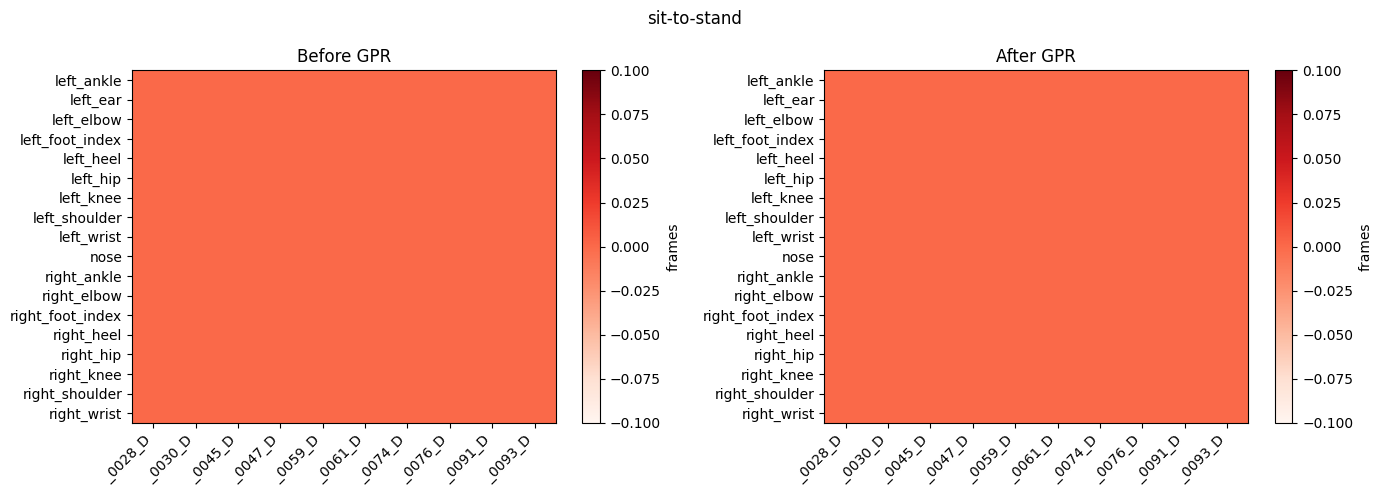


=== stand-to-sit ===
Before: 0 missing frames
After:  0 missing frames
Rescued: 0 (0.0%)
No frames rescued.


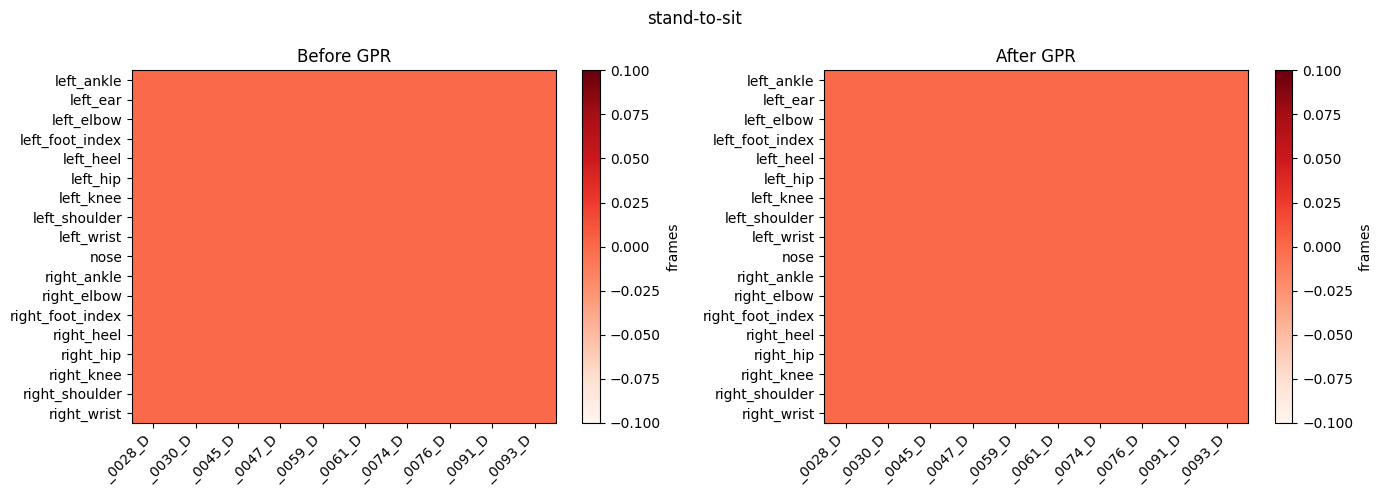

In [8]:
import matplotlib.pyplot as plt

for out_csv, label in [(OUT_CSV, 'sit-to-stand'), (DOWN_OUT_CSV, 'stand-to-sit')]:
    missing_before = missing_before_all[label]
    total_before   = missing_before['missing_before'].sum()

    after_rows = []
    for csv_path in sorted(out_csv.glob('*.csv')):
        df = pd.read_csv(csv_path)
        for joint in ALL_JOINTS:
            src_col = f'{joint}_source'
            if src_col not in df.columns:
                continue
            counts = df[src_col].value_counts()
            after_rows.append({
                'video':         csv_path.stem,
                'joint':         joint,
                'missing_after': counts.get('missing', 0),
                'gpr':           counts.get('gpr', 0),
            })

    missing_after = pd.DataFrame(after_rows)
    total_after   = missing_after['missing_after'].sum()

    comp = missing_before.merge(missing_after, on=['video', 'joint'])
    comp['rescued'] = comp['missing_before'] - comp['missing_after']

    print(f'\n=== {label} ===')
    print(f'Before: {total_before} missing frames')
    print(f'After:  {total_after} missing frames')
    print(f'Rescued: {total_before - total_after} ({(total_before - total_after) / max(total_before, 1) * 100:.1f}%)')

    changed = comp[comp['rescued'] != 0][['video', 'joint', 'missing_before', 'gpr', 'missing_after', 'rescued']]
    if changed.empty:
        print('No frames rescued.')
    else:
        print(changed.to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(max(8, len(comp['video'].unique()) * 1.4), 5))
    fig.suptitle(label)
    for ax, col, title in zip(axes,
                               ['missing_before', 'missing_after'],
                               ['Before GPR', 'After GPR']):
        pivot = comp.pivot(index='joint', columns='video', values=col).fillna(0).astype(int)
        im = ax.imshow(pivot.values, aspect='auto', cmap='Reds',
                       vmin=0, vmax=comp['missing_before'].max())
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([c[-7:] for c in pivot.columns], rotation=45, ha='right')
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                v = pivot.values[i, j]
                if v > 0:
                    ax.text(j, i, str(v), ha='center', va='center', fontsize=8)
        ax.set_title(title)
        plt.colorbar(im, ax=ax, label='frames')

    plt.tight_layout()
    plt.show()